In [1]:
import os 
import gemmi 


In [2]:
folder_containing_all_atomic_models = "/home/abharadwaj1/papers/elife_paper/figure_information/data/deposited_atomic_models"
folder_containing_hydrogenated_atomic_models = "/home/abharadwaj1/papers/elife_paper/figure_information/data/atomic_models_with_hydrogen"



In [3]:
deposited_model_paths = [os.path.join(folder_containing_all_atomic_models, f) for f in os.listdir(folder_containing_all_atomic_models) if f.endswith(".pdb") and "servalcat_refined" in f]
hydrogenated_model_paths = [os.path.join(folder_containing_hydrogenated_atomic_models, f) for f in os.listdir(folder_containing_hydrogenated_atomic_models) if f.endswith(".pdb")]

print("Number of deposited models:", len(deposited_model_paths))
print("Number of hydrogenated models:", len(hydrogenated_model_paths))

Number of deposited models: 125
Number of hydrogenated models: 120


In [8]:
pdb_ids_in_deposited_models = [os.path.basename(f).split("_")[1] for f in deposited_model_paths]
pdb_ids_in_hydrogenated_models = [os.path.basename(f).split("_")[1] for f in hydrogenated_model_paths]

common_pdb_ids = list(set(pdb_ids_in_deposited_models) & set(pdb_ids_in_hydrogenated_models))
print(f"Length of common pdb ids: {len(common_pdb_ids)}")


Length of common pdb ids: 119


In [6]:
deposited_models_dictionary = {pdb_id : [f for f in deposited_model_paths if pdb_id in f][0] for pdb_id in pdb_ids_in_deposited_models}
hydrogenated_models_dictionary = {pdb_id : [f for f in hydrogenated_model_paths if pdb_id in f][0] for pdb_id in pdb_ids_in_hydrogenated_models}

assert len(deposited_models_dictionary) == len(pdb_ids_in_deposited_models)

In [40]:
test_pdb_id = common_pdb_ids[0]
print("Test PDB ID:", test_pdb_id)
test_deposited_model_path = deposited_models_dictionary[test_pdb_id]
test_hydrogenated_model_path = hydrogenated_models_dictionary[test_pdb_id]
print("Test deposited model path:", test_deposited_model_path)
print("Test hydrogenated model path:", test_hydrogenated_model_path)
st_deposited = gemmi.read_structure(test_deposited_model_path)
st_hydrogenated = gemmi.read_structure(test_hydrogenated_model_path)

Test PDB ID: 6nzu
Test deposited model path: /home/abharadwaj1/papers/elife_paper/figure_information/data/deposited_atomic_models/PDB_6nzu_unrefined_shifted_servalcat_refined_shifted_servalcat_refined.pdb
Test hydrogenated model path: /home/abharadwaj1/papers/elife_paper/figure_information/data/atomic_models_with_hydrogen/0560_6nzu_hydrogenated_model.pdb


In [41]:
# Compute the number of atoms in each model
num_atoms_deposited = 0 
num_atoms_hydrogenated = 0
for model in st_deposited:
    for chain in model:
        for res in chain: 
            for atom in res:
                num_atoms_deposited += 1
for model in st_hydrogenated:
    for chain in model:
        for res in chain: 
            for atom in res:
                num_atoms_hydrogenated += 1
print(f"Number of atoms in deposited model: {num_atoms_deposited}")
print(f"Number of atoms in hydrogenated model: {num_atoms_hydrogenated}")



Number of atoms in deposited model: 12570
Number of atoms in hydrogenated model: 25270


In [42]:
def get_molecular_weight_from_structure(st):
    """
    Get the molecular weight of a deposited structure from RCSB PDB.
    
    Args:
        pdbid (str): The PDB ID of the structure.
        
    Returns:
        float: Molecular weight in kDa.
    """
    all_atoms = [cra.atom for cra in st[0].all()]
    all_atom_weight = sum([a.element.weight for a in all_atoms])
    molecular_weight_kda = all_atom_weight / 1000.0
    return molecular_weight_kda
    

In [43]:
# atomic weight 
molecular_weight_deposited = get_molecular_weight_from_structure(st_deposited)
molecular_weight_hydrogenated = get_molecular_weight_from_structure(st_hydrogenated)
print(f"Molecular weight of deposited model: {molecular_weight_deposited:.2f} kDa")
print(f"Molecular weight of hydrogenated model: {molecular_weight_hydrogenated:.2f} kDa")

Molecular weight of deposited model: 166.34 kDa
Molecular weight of hydrogenated model: 179.14 kDa


In [44]:
# measure average atomic weight from hydrogenated and non-hydrogenated models
average_atomic_weight_deposited = molecular_weight_deposited / num_atoms_deposited * 1000
average_atomic_weight_hydrogenated = molecular_weight_hydrogenated / num_atoms_hydrogenated * 1000

print(f"Average atomic weight of deposited model: {average_atomic_weight_deposited:.4f} Da")
print(f"Average atomic weight of hydrogenated model: {average_atomic_weight_hydrogenated:.4f} Da")

Average atomic weight of deposited model: 13.2328 Da
Average atomic weight of hydrogenated model: 7.0889 Da


In [21]:
# get average atomic for all deposited models and 
average_atomic_weight_deposited_models_all = {} 
average_atomic_weight_hydrogenated_models_all = {}
for pdb_id in common_pdb_ids:
    st_deposited = gemmi.read_structure(deposited_models_dictionary[pdb_id])
    st_hydrogenated = gemmi.read_structure(hydrogenated_models_dictionary[pdb_id])
    
    num_atoms_deposited = st_deposited[0].count_atom_sites()
    num_atoms_hydrogenated = st_hydrogenated[0].count_atom_sites()
    molecular_weight_deposited = get_molecular_weight_from_structure(st_deposited)
    molecular_weight_hydrogenated = get_molecular_weight_from_structure(st_hydrogenated)
    average_atomic_weight_deposited = molecular_weight_deposited / num_atoms_deposited * 1000
    average_atomic_weight_hydrogenated = molecular_weight_hydrogenated / num_atoms_hydrogenated * 1000
    average_atomic_weight_deposited_models_all[pdb_id] = average_atomic_weight_deposited
    average_atomic_weight_hydrogenated_models_all[pdb_id] = average_atomic_weight_hydrogenated

In [53]:
len(common_pdb_ids)

119

Most common atomic weight of deposited models: 13.2022 Da
Most common atomic weight of hydrogenated models: 7.0988 Da


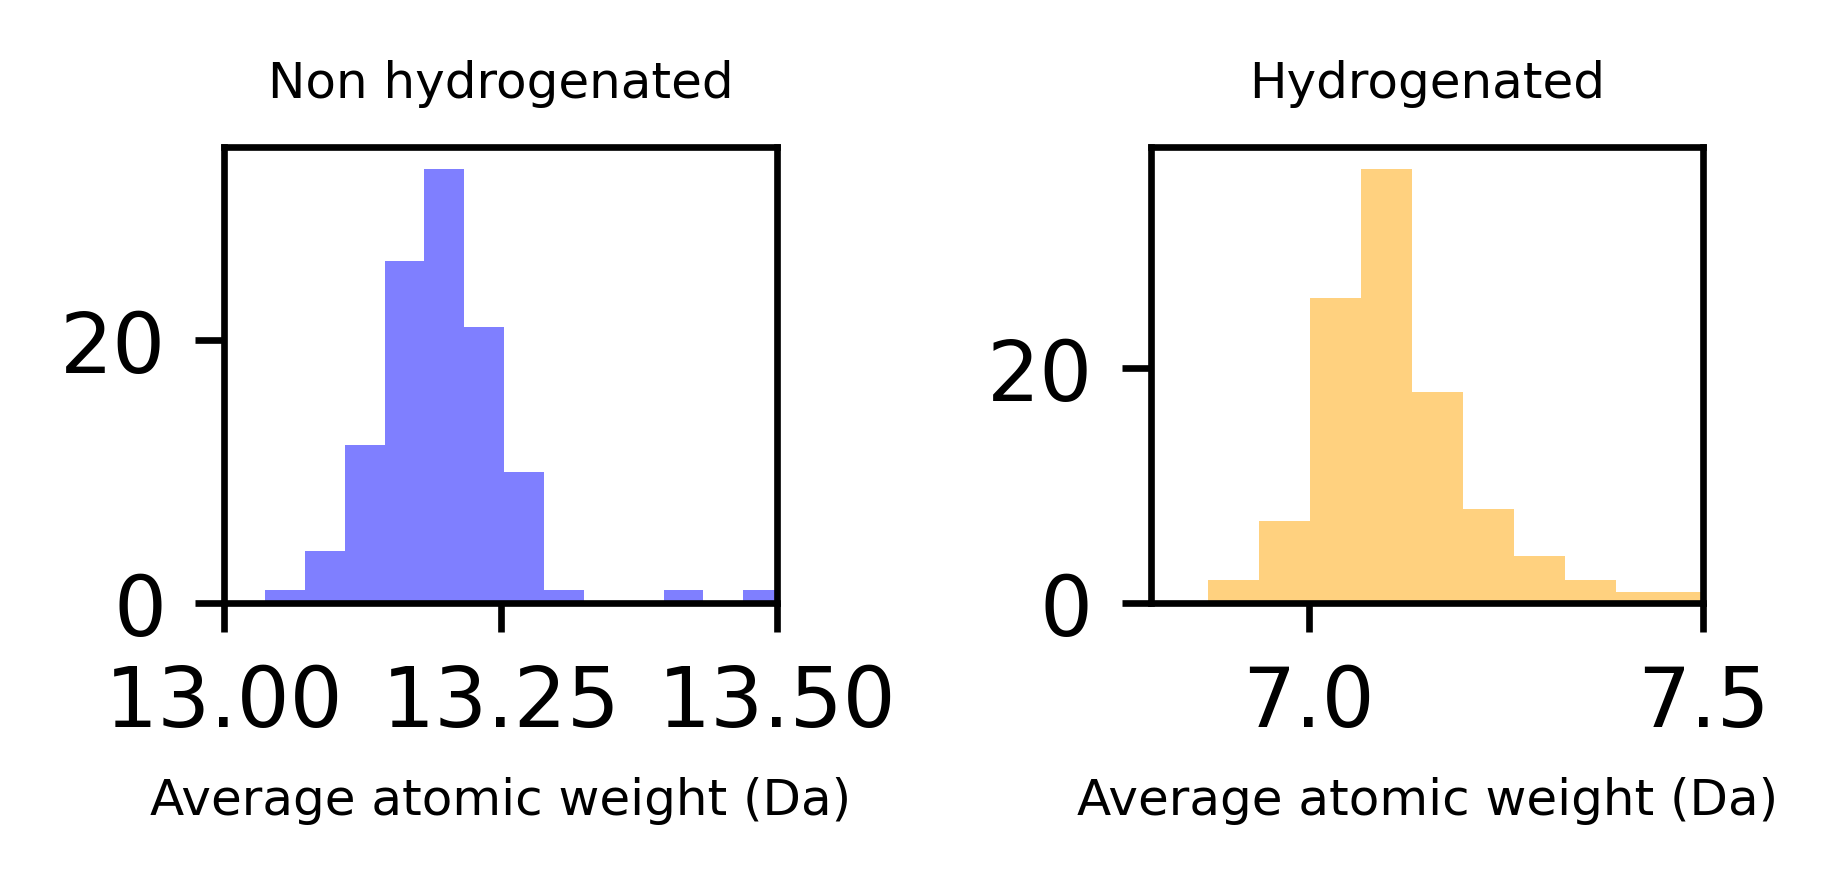

In [52]:
# plot histograms of average atomic weights
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
figsize_mm = (80, 40)
fig, ax = plt.subplots(1, 2, figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4), dpi=600)
average_atomic_weight_deposited_models_all_numpy = np.array(list(average_atomic_weight_deposited_models_all.values()))
average_atomic_weight_hydrogenated_models_all_numpy = np.array(list(average_atomic_weight_hydrogenated_models_all.values()))
ax[0].hist(average_atomic_weight_deposited_models_all_numpy, bins=30, alpha=0.5, label='Non hydrogenated Models', color='blue')
ax[1].hist(average_atomic_weight_hydrogenated_models_all_numpy, bins=30, alpha=0.5, label='Hydrogenated Models', color='orange')
ax[0].set_title("Non hydrogenated", fontsize=6)
ax[1].set_title("Hydrogenated", fontsize=6)
ax[0].set_xlabel("Average atomic weight (Da)", fontsize=6)
ax[1].set_xlabel("Average atomic weight (Da)", fontsize=6)
ax[0].set_xlim(13, 13.5)
ax[1].set_xlim(6.8, 7.5)
fig.tight_layout()

most_common_atomic_weight_deposited = np.median(average_atomic_weight_deposited_models_all_numpy)
most_common_atomic_weight_hydrogenated = np.median(average_atomic_weight_hydrogenated_models_all_numpy)
print(f"Most common atomic weight of deposited models: {most_common_atomic_weight_deposited:.4f} Da")
print(f"Most common atomic weight of hydrogenated models: {most_common_atomic_weight_hydrogenated:.4f} Da")



In [45]:
random_atom = st_deposited[0][0][0][0]
random_atom.element.vdw_r
print("Random atom:", random_atom)

Random atom: <gemmi.Atom N at (86.4, 98.7, 127.5)>


In [49]:
# compute vander-waals volume of the deposited model
atomic_volume = 0 
for model in st_deposited:
    for chain in model:
        for res in chain: 
            for atom in res:
                atomic_volume += atom.element.vdw_r**3 * 4/3 * np.pi
print(f"Total vander-waals volume of deposited model: {atomic_volume:.2f} Angstrom^3")
# compute density of the deposited model
density_deposited = molecular_weight_deposited *1000 / atomic_volume # in kDa / Angstrom^3
density_deposited_g_cm3 = density_deposited / 1.66054 # convert to g/cm^3

print(f"Density of deposited model: {density_deposited_g_cm3:.2f} g/cm^3")

Total vander-waals volume of deposited model: 233845.24 Angstrom^3
Density of deposited model: 0.43 g/cm^3


In [39]:
molecular_weight_deposited

423.02983331194696